In [1]:
import torch
torch.cuda.empty_cache()

In [ ]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import numpy as np
from tqdm.auto import tqdm
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Add parent directories to path
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import (
    PROJECT_ROOT,
    SAMPLING_RATE,
    XLSR_MAX_TIME_STEPS
)
from model import SSLModel, AD_XLSR_Model
from data_split import create_train_val_split
from visualization import plot_training_curves, plot_dataset_comparison


2025-12-22 11:05:23 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [ ]:
DATASET_NAME = "ADReSS"
FEATURE_TYPE = "xlsr_finetune"

# Paths
# Use raw audio directory for fine-tuning (loading original audio files)
RAW_AUDIO_DIR = Path("/root/autodl-tmp/data/raw/ADReSS")
# CSV files are in processed directory
TRAIN_CSV = Path("/root/autodl-tmp/data/processed") / f"{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = Path("/root/autodl-tmp/data/processed") / f"{DATASET_NAME}-xlsr-val.csv"
# Save models to data disk (autodl-tmp) to avoid filling up system disk
DATA_DISK = Path("/root/autodl-tmp")
MODEL_OUTPUT_DIR = DATA_DISK / "models" / f"{DATASET_NAME}_{FEATURE_TYPE}_multi_seed"

# Training hyperparameters
AUDIO_LENGTH_SEC = 60 # Reduced from 60s to 40s to save memory on MPS
FINETUNE_BATCH_SIZE = 4  # Batch size for fine-tuning (must be 1 for MPS memory constraints)
ACCUMULATION_STEPS = 4  # Gradient accumulation steps to simulate effective batch size of 4
XLSR_LR = 1e-5
CLASSIFIER_LR = 1e-3
FINETUNE_MAX_EPOCHS = 50  # Maximum training epochs
FINETUNE_PATIENCE = 10  # Early stopping patience (stop if no improvement for 5 epochs)
NUM_WORKERS = 0

# Fine-tuning specific hyperparameters
NUM_FINETUNE_LAYERS = 3
CLASS_WEIGHT_CONTROL = 1.0
CLASS_WEIGHT_DEMENTIA = 1.2

XLSR_DROPOUT = 0.4    
WEIGHT_DECAY = 5e-2

Dataset: ADReSS
Model output directory: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed
Audio length: 60 seconds
Batch size: 4
Gradient accumulation steps: 4 (effective batch size: 16)
XLSR learning rate: 1e-05
Classifier learning rate: 0.001
Max epochs: 50
Early stopping patience: 10
Fine-tune layers: last 3 transformer layers
Class weights: Control=1.0, Dementia=1.2


## Device Setup


In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    accelerator = 'gpu'
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    accelerator = 'mps'
else:
    device = torch.device('cpu')
    accelerator = 'cpu'
    
print(f"Using device: {device}")


Using device: cuda


## Step 1: Data Preparation

Create train/validation split using existing CSV files


In [5]:
# Use existing split function to create/load CSV files
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    feature_dir_name=f"{DATASET_NAME}_xlsr_features",  # Not used but required
    dataset_name=DATASET_NAME,
    xlsr=True
)


============= ADReSS Train(80.0%) and Val(20%) Split Complete! =============
Training set: 124 samples (Control: 62, Dementia: 62)
Validation set: 32 samples (Control: 16, Dementia: 16)


In [6]:
def train_one_epoch(model, train_loader, optimizer, device, epoch=None, accumulation_steps=1, class_weights=None):
    """Train for one epoch with gradient accumulation"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    desc = f"Epoch {epoch} - Training" if epoch is not None else "Training"
    pbar = tqdm(train_loader, desc=desc, leave=False)
    
    optimizer.zero_grad()
    
    for batch_idx, (waveforms, labels) in enumerate(pbar):
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        
        # Forward pass
        logits = model(waveforms)
        loss = F.cross_entropy(logits, labels, weight=class_weights)
        
        # Scale loss for gradient accumulation
        loss = loss / accumulation_steps

        # Backward pass
        loss.backward()
        
        # Update weights only after accumulation_steps
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()

        # Statistics (use unscaled loss for reporting)
        total_loss += loss.item() * accumulation_steps
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        # Update progress bar
        current_loss = total_loss / (batch_idx + 1)
        current_acc = correct / total
        pbar.set_postfix({'loss': f'{current_loss:.4f}', 'acc': f'{current_acc:.4f}'})

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, val_loader, device, epoch=None):
    """Validate model and compute detailed metrics"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # For per-class metrics
    control_correct = 0
    control_total = 0
    dementia_correct = 0
    dementia_total = 0

    # For F1 score
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    desc = f"Epoch {epoch} - Validation" if epoch is not None else "Validation"
    pbar = tqdm(val_loader, desc=desc, leave=False)

    with torch.no_grad():
        for waveforms, labels in pbar:
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            
            logits = model(waveforms)
            loss = F.cross_entropy(logits, labels)
            predictions = torch.argmax(logits, dim=1)

            # Overall statistics
            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Per-class accuracy
            for pred, label in zip(predictions, labels):
                if label == 0:  # Control
                    control_total += 1
                    if pred == label:
                        control_correct += 1
                else:  # Dementia
                    dementia_total += 1
                    if pred == label:
                        dementia_correct += 1

                # F1 score components
                if pred == 1 and label == 1:
                    true_positives += 1
                elif pred == 1 and label == 0:
                    false_positives += 1
                elif pred == 0 and label == 1:
                    false_negatives += 1
            
            # Update progress bar
            current_loss = total_loss / (pbar.n + 1)
            current_acc = correct / total
            pbar.set_postfix({'loss': f'{current_loss:.4f}', 'acc': f'{current_acc:.4f}'})

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total

    # Per-class accuracy
    control_acc = control_correct / control_total if control_total > 0 else 0
    dementia_acc = dementia_correct / dementia_total if dementia_total > 0 else 0

    # F1 score
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return avg_loss, accuracy, control_acc, dementia_acc, f1_score


In [7]:
class AudioDataset(Dataset):
    """
    Dataset for loading audio files directly for XLSR fine-tuning
    
    Args:
        csv_path: Path to CSV file containing session IDs and labels
        audio_dir: Root directory for audio files (should contain Control/ and Dementia/ subdirs)
        max_length_sec: Maximum audio length in seconds
        sampling_rate: Target sampling rate
    """
    def __init__(self, csv_path, audio_dir, max_length_sec=60, sampling_rate=16000):
        self.csv_path = csv_path
        self.audio_dir = Path(audio_dir)
        self.max_length_sec = max_length_sec
        self.sampling_rate = sampling_rate
        self.max_samples = max_length_sec * sampling_rate
        
        # Load data from CSV
        self.data = []
        df = pd.read_csv(csv_path)
        
        for _, row in df.iterrows():
            session_id = row['session_id']
            label = int(row['ad'])
            
            # Construct audio file path based on label
            # 0 = Control, 1 = Dementia
            label_dir = "Dementia" if label == 1 else "Control"
            
            # Try different audio extensions
            found = False
            for ext in ['.wav', '.mp3', '.flac']:
                audio_path = self.audio_dir / label_dir / f"{session_id}{ext}"
                if audio_path.exists():
                    self.data.append({
                        'session_id': session_id,
                        'audio_path': audio_path,
                        'label': label
                    })
                    found = True
                    break
            
            if not found:
                print(f"Warning: Audio file not found for session {session_id} in {label_dir}/")
        
        print(f"Loaded {len(self.data)} audio files")
        control_count = sum(1 for d in self.data if d['label'] == 0)
        dementia_count = sum(1 for d in self.data if d['label'] == 1)
        print(f"Control: {control_count}, Dementia: {dementia_count}\n")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        audio_path = item['audio_path']
        label = item['label']
        
        # Load audio
        waveform, sr = torchaudio.load(audio_path)
        
        # Resample if necessary
        if sr != self.sampling_rate:
            resampler = torchaudio.transforms.Resample(sr, self.sampling_rate)
            waveform = resampler(waveform)
        
        # Convert to mono if stereo
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        
        # Squeeze to 1D
        waveform = waveform.squeeze(0)
        
        # Pad or truncate to max_samples
        if waveform.shape[0] > self.max_samples:
            waveform = waveform[:self.max_samples]
        elif waveform.shape[0] < self.max_samples:
            padding = self.max_samples - waveform.shape[0]
            waveform = F.pad(waveform, (0, padding))
        
        return waveform, label


def collate_audio_batch(batch):
    """
    Collate function for audio batch
    Returns:
        waveforms: (batch_size, time)
        labels: (batch_size,)
    """
    waveforms = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    
    waveforms = torch.stack(waveforms)
    labels = torch.tensor(labels, dtype=torch.long)
    
    return waveforms, labels


## Step 3: Create Data Loaders


In [8]:
# Create datasets
train_dataset = AudioDataset(
    csv_path=TRAIN_CSV,
    audio_dir=RAW_AUDIO_DIR,
    max_length_sec=AUDIO_LENGTH_SEC,
    sampling_rate=SAMPLING_RATE
)

val_dataset = AudioDataset(
    csv_path=VAL_CSV,
    audio_dir=RAW_AUDIO_DIR,
    max_length_sec=AUDIO_LENGTH_SEC,
    sampling_rate=SAMPLING_RATE
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_audio_batch,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_audio_batch,
    pin_memory=torch.cuda.is_available()
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Loaded 124 audio files
Control: 62, Dementia: 62

Loaded 32 audio files
Control: 16, Dementia: 16

Train batches: 31
Val batches: 8


## Step 4: Define Fine-tuning Model

Create an end-to-end model that combines XLSR feature extraction with the AD classifier


In [9]:
class XLSR_Finetune_Model(nn.Module):
    """
    End-to-end XLSR fine-tuning model for AD detection
    
    Combines:
    1. SSLModel (XLSR-53) - only last 3 transformer layers are trainable
    2. AD_XLSR_Model - AD classification head
    """
    def __init__(self, device, dropout=0.2, num_finetune_layers=NUM_FINETUNE_LAYERS):
        super().__init__()
        
        # XLSR feature extractor (freeze all first)
        self.ssl_model = SSLModel(device=device, freeze_xlsr=True)
        
        # Unfreeze only the last N transformer layers
        encoder_layers = self.ssl_model.model.encoder.layers
        total_layers = len(encoder_layers)
        for i, layer in enumerate(encoder_layers):
            if i >= total_layers - num_finetune_layers:
                for param in layer.parameters():
                    param.requires_grad = True
        
        self.ssl_model.model.train()
        print(f"XLSR: Training layers {total_layers - num_finetune_layers} to {total_layers - 1}")
        
        # AD classifier
        self.classifier = AD_XLSR_Model(dropout=dropout)
        
        self.device = device
    
    def forward(self, waveform, mask=None):
        """
        Args:
            waveform: (batch_size, time) - raw audio waveform
            mask: Optional attention mask (not used in current implementation)
        
        Returns:
            logits: (batch_size, 2) - AD classification logits
        """
        # Extract XLSR features
        # embedding: (batch_size, time_downsampled, 1024)
        embedding, _ = self.ssl_model.extract_feat(waveform)
        
        # Create attention mask based on feature length
        batch_size, seq_len, _ = embedding.shape
        
        # Pad or truncate to XLSR_MAX_TIME_STEPS
        if seq_len > XLSR_MAX_TIME_STEPS:
            embedding = embedding[:, :XLSR_MAX_TIME_STEPS, :]
            mask = torch.ones(batch_size, XLSR_MAX_TIME_STEPS, device=self.device)
        elif seq_len < XLSR_MAX_TIME_STEPS:
            padding = torch.zeros(batch_size, XLSR_MAX_TIME_STEPS - seq_len, 1024, device=self.device)
            embedding = torch.cat([embedding, padding], dim=1)
            mask = torch.ones(batch_size, XLSR_MAX_TIME_STEPS, device=self.device)
            mask[:, seq_len:] = 0
        else:
            mask = torch.ones(batch_size, seq_len, device=self.device)
        
        # Classify
        logits = self.classifier(embedding, mask)
        
        return logits


## Step 5: Training Functions


In [ ]:
def train_finetune(seed, train_loader, val_loader, output_dir, device):
    """
    Fine-tuning pipeline for XLSR model
    
    Args:
        seed: Random seed
        train_loader: Training data loader
        val_loader: Validation data loader
        output_dir: Directory to save models
        device: Device to train on
    
    Returns:
        seed: The seed used
        best_metrics: Dictionary of best validation metrics
        training_history: Dictionary of training history
    """
    # Set random seed
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    np.random.seed(seed)

    # Create save directory
    seed_dir = Path(output_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    # Create model
    model = XLSR_Finetune_Model(device=device, dropout=XLSR_DROPOUT).to(device)
    
    # Create optimizer with differential learning rates
    # XLSR (ssl_model): only trainable params (last 3 layers), smaller learning rate
    # Classifier: larger learning rate for faster adaptation
    xlsr_trainable_params = [p for p in model.ssl_model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': xlsr_trainable_params, 'lr': XLSR_LR},
        {'params': model.classifier.parameters(), 'lr': CLASSIFIER_LR}
    ], weight_decay=WEIGHT_DECAY)

    # Set class weights from hyperparameters
    class_weights = torch.tensor([CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA], device=device)

    # Training history
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    epochs_list = []

    # Early stopping
    best_val_acc = 0
    best_val_loss = float('inf')
    best_metrics = {}
    patience_counter = 0
    best_epoch = 0
    stopped_epoch = 0

    print(f"\n{'='*70}")
    print(f"Training with seed {seed}")
    print(f"Class weights: Control={class_weights[0]:.1f}, Dementia={class_weights[1]:.1f}")
    print(f"{'='*70}")

    # Training loop
    for epoch in range(FINETUNE_MAX_EPOCHS):
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device, epoch=epoch+1, accumulation_steps=ACCUMULATION_STEPS, class_weights=class_weights)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validate
        val_loss, val_acc, control_acc, dementia_acc, f1 = validate(model, val_loader, device, epoch=epoch+1)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        epochs_list.append(epoch)

        # Print epoch results
        print(f"Epoch {epoch+1}/{FINETUNE_MAX_EPOCHS} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}% | "
              f"Control: {control_acc*100:.2f}%, Dementia: {dementia_acc*100:.2f}%, F1: {f1:.4f}")

        # Save best model based on highest accuracy, then lowest loss
        is_best = False
        if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_metrics = {
                'val_acc': val_acc,
                'val_loss': val_loss,
                'control_acc': control_acc,
                'dementia_acc': dementia_acc,
                'f1_score': f1
            }
            patience_counter = 0
            is_best = True
            
            # Save fine-tuned XLSR model
            torch.save({
                'ssl_model_state_dict': model.ssl_model.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'best_val_loss': best_val_loss,
            }, seed_dir / 'best_xlsr.pth')
            
            # Save classifier model
            torch.save({
                'classifier_state_dict': model.classifier.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'best_val_loss': best_val_loss,
            }, seed_dir / 'best_classifier.pth')
            
            # Save optimizer state
            torch.save({
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'best_val_loss': best_val_loss,
            }, seed_dir / 'optimizer.pth')
            
            print(f"  *** New best model saved! (Acc: {val_acc*100:.2f}%, Loss: {val_loss:.4f}) ***")
            print(f"      - Fine-tuned XLSR: best_xlsr.pth")
            print(f"      - Classifier: best_classifier.pth")
            print(f"      - Optimizer: optimizer.pth")
        else:
            patience_counter += 1

        # Early stopping check
        if patience_counter >= FINETUNE_PATIENCE:
            stopped_epoch = epoch + 1
            print(f"\nEarly stopping triggered after {FINETUNE_PATIENCE} epochs without improvement")
            break

    # Print final results
    print(f"\n{'='*70}")
    print(f"Training completed for seed {seed}")
    print(f"{'='*70}")
    print(f"Best Validation Accuracy: {best_metrics['val_acc']*100:.2f}%")
    print(f"Best Validation Loss: {best_metrics['val_loss']:.4f}")
    print(f"F1 Score: {best_metrics['f1_score']:.4f}")
    print(f"Control Accuracy: {best_metrics['control_acc']*100:.2f}%")
    print(f"Dementia Accuracy: {best_metrics['dementia_acc']*100:.2f}%")
    print(f"Best epoch: {best_epoch}")
    print(f"Stopped at epoch: {stopped_epoch if stopped_epoch > 0 else FINETUNE_MAX_EPOCHS}")
    print(f"{'='*70}\n")

    # Return training history along with best metrics
    training_history = {
        'epochs': epochs_list,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

    return seed, best_metrics, training_history


## Step 7: Train with Multiple Seeds


In [11]:
# Initialize results storage
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}


## Random Seed 21

wandb: Currently logged in as: sunluqi581 (sunluqi581-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


XLSR:Using original XLSR model


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Training layers 21 to 23

Training with seed 21
Class weights: Control=1.0, Dementia=1.2


Epoch 1 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 39/50 - Train Loss: 0.1777, Train Acc: 94.35% - Val Loss: 0.6010, Val Acc: 68.75% | Control: 68.75%, Dementia: 68.75%, F1: 0.6875


Epoch 40 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 40 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 40/50 - Train Loss: 0.2009, Train Acc: 94.35% - Val Loss: 0.7158, Val Acc: 68.75% | Control: 68.75%, Dementia: 68.75%, F1: 0.6875

Early stopping triggered after 10 epochs without improvement

Training completed for seed 21
Best Validation Accuracy: 84.38%
Best Validation Loss: 0.3963
F1 Score: 0.8485
Control Accuracy: 81.25%
Dementia Accuracy: 87.50%
Best epoch: 30
Stopped at epoch: 40



control_acc,▁▂▃▂▃▃▃▄▅▅▅▇▅▆▇█▅▇▅▅█▅▇▇▇▆▇▆▆█▄▇▆▇▆▇█▇▇▇
dementia_acc,█▇▆▆▆▆▅▃▅▃▂▂▁▇▅▃▅▆▅▅▂▆▇▆▇▆▇▅▅▆▅▅▇▅▆▃▃▆▂▂
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
f1_score,▃▃▃▂▃▃▂▂▄▃▂▄▁▇▆▆▄▇▄▄▅▄█▇█▆█▅▅█▃▆▇▆▆▅▆▇▄▄
train_acc,▁▂▃▃▃▄▄▅▄▆▄▆▆▆▆▇▆▇▆▇▇▇▇███▇███▇█▆▇█▇████
train_loss,█▇▇▇▇▆▆▆▆▅▅▅▅▄▅▃▄▃▄▃▃▄▃▂▂▂▃▂▂▁▃▁▃▂▂▂▁▂▂▂
val_acc,▁▁▂▁▂▂▂▂▄▃▃▅▂▇▆▇▄▇▄▄▆▄▇▇▇▅▇▅▅█▃▆▇▆▆▆▇▇▅▅
val_loss,▄▄▄▄▄▄▄▅▂▄▄▃▃▂▃▂▂▁▂▄▂▃▁▁▂▁▁▂▃▁█▄▂▂▃▃▂▂▃▄
best_control_acc,0.8125
best_dementia_acc,0.875
best_epoch,30


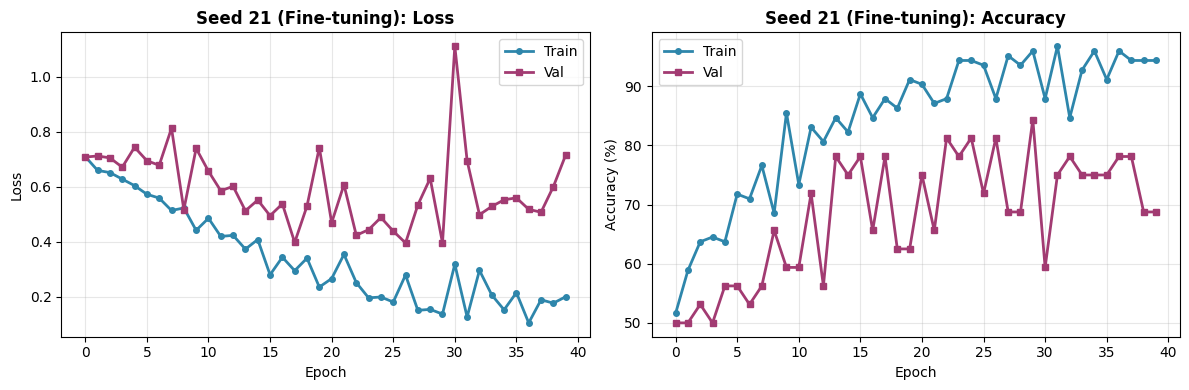

In [12]:
seed, metrics, history = train_finetune(
    seed=21,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device
)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed} (Fine-tuning)'
)


In [13]:
torch.cuda.empty_cache()

## 42

XLSR:Using original XLSR model


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Training layers 21 to 23

Training with seed 42
Class weights: Control=1.0, Dementia=1.2


Epoch 1 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 30/50 - Train Loss: 0.3084, Train Acc: 87.10% - Val Loss: 0.5527, Val Acc: 75.00% | Control: 68.75%, Dementia: 81.25%, F1: 0.7647


Epoch 31 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 31 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 31/50 - Train Loss: 0.2218, Train Acc: 90.32% - Val Loss: 0.6533, Val Acc: 75.00% | Control: 68.75%, Dementia: 81.25%, F1: 0.7647

Early stopping triggered after 10 epochs without improvement

Training completed for seed 42
Best Validation Accuracy: 81.25%
Best Validation Loss: 0.4680
F1 Score: 0.8235
Control Accuracy: 75.00%
Dementia Accuracy: 87.50%
Best epoch: 21
Stopped at epoch: 31



control_acc,▃▃▆▄▆▆▂▃▆▄▅▆▇▆▅▅▇██▄█▆▇▇▃▁▅██▇▇
dementia_acc,▃▃▃▃▁▃▅▅▅▅▇▄▅▅▆▅▄▅▅▅▆▅▅▅▇█▆▄▃▅▅
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
f1_score,▁▁▄▂▁▄▃▄▅▄▇▄▆▆▆▅▅▇▇▄█▅▆▆▆▅▆▆▅▆▆
train_acc,▁▂▂▂▂▃▃▅▅▅▅▆▅▆▅▆▅█▆▇▇█▇▇▇▆▇▇▇▆▇
train_loss,███▇█▇▇▆▆▅▅▄▅▄▅▄▄▂▃▃▂▁▁▁▂▃▃▂▃▃▂
val_acc,▁▁▅▂▂▅▂▃▅▄▆▅▇▆▅▅▆▇▇▄█▅▇▇▅▃▅▇▆▇▇
val_loss,▃▃▃▃▂▃▂▂▂▃▂▂▁▃▃▂▁▂▂▂▁▂▂▁▅█▃▁▂▂▂
best_control_acc,0.75
best_dementia_acc,0.875
best_epoch,21


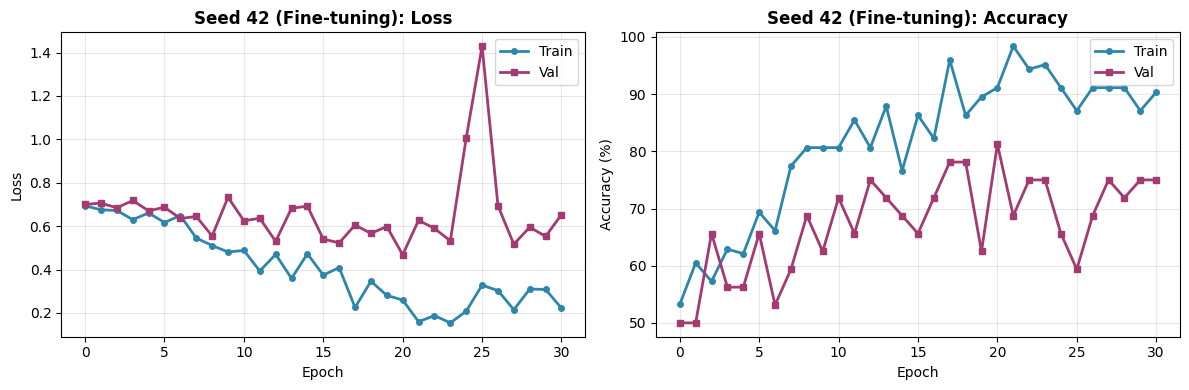

In [14]:
seed, metrics, history = train_finetune(
    seed=42,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device
)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed} (Fine-tuning)'
)


In [15]:
torch.cuda.empty_cache()

## 84

XLSR:Using original XLSR model
XLSR: Training layers 21 to 23

Training with seed 84
Class weights: Control=1.0, Dementia=1.2


Epoch 1 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 0.6868, Train Acc: 54.84% - Val Loss: 0.6968, Val Acc: 46.88% | Control: 6.25%, Dementia: 87.50%, F1: 0.6222
  *** New best model saved! (Acc: 46.88%, Loss: 0.6968) ***
      - Fine-tuned XLSR: best_xlsr.pth
      - Classifier: best_classifier.pth
      - Optimizer: optimizer.pth


Epoch 2 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 46/50 - Train Loss: 0.2087, Train Acc: 92.74% - Val Loss: 0.8188, Val Acc: 65.62% | Control: 75.00%, Dementia: 56.25%, F1: 0.6207


Epoch 47 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 47 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 47/50 - Train Loss: 0.2055, Train Acc: 93.55% - Val Loss: 0.7436, Val Acc: 75.00% | Control: 75.00%, Dementia: 75.00%, F1: 0.7500

Early stopping triggered after 10 epochs without improvement

Training completed for seed 84
Best Validation Accuracy: 81.25%
Best Validation Loss: 0.6086
F1 Score: 0.7857
Control Accuracy: 93.75%
Dementia Accuracy: 68.75%
Best epoch: 37
Stopped at epoch: 47



control_acc,▁▃▃▄▃▁▅▅▇▅▅▆▇▇▅▇▇▅▅█▅▆▅▅▅▇▇▇▆▆▅█▇▇▆▇▅▅▅▇
dementia_acc,█▅▆▅▅█▂█▅▇▆▁▃▃▇▃▅▆▅▃▆▁▆▆▅▆▅▅▆▃▆▅▃▆▆▃▆▆▆▆
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
f1_score,▃▂▃▃▂▃▁▇▆▆▄▁▆▆▆▆▅▅▄▆▅▁▅▅▄█▇▇▆▄▅█▆▇▆▅▅▅▅▇
train_acc,▁▂▂▂▂▃▄▃▄▅▅▆▆▆▆▇▆▇▇▇▇▇▅█▇▇▇▇▇▆█▇█▇▇▆▇██▇
train_loss,████▇▇▆▆▆▅▅▄▃▃▄▃▄▃▂▂▃▂▄▁▃▂▁▂▂▄▁▁▁▃▃▄▂▂▁▂
val_acc,▁▂▂▃▂▂▃▆▇▅▄▄▇▇▅▇▆▅▄▇▅▄▅▅▄█▇▇▆▅▅█▇▇▆▆▅▅▅▇
val_loss,▄▄▄▄▅▄▃▅▃▃▄▂▁▂▄▂▂▄▃▂▆▇█▆▄▄▃▂▆▃▄▃▃▆▇▃▄▅▅▅
best_control_acc,0.9375
best_dementia_acc,0.6875
best_epoch,37


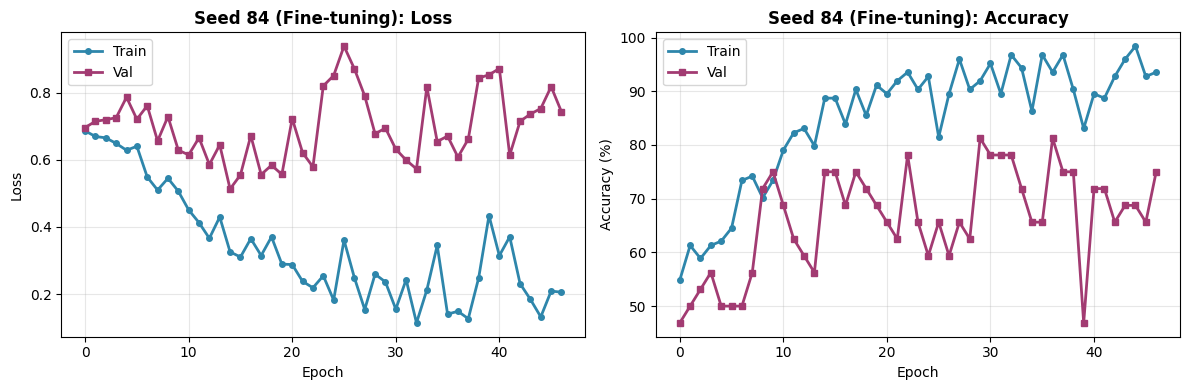

In [16]:
seed, metrics, history = train_finetune(
    seed=84,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device
)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed} (Fine-tuning)'
)


In [17]:
import torch
torch.cuda.empty_cache()

## 168

XLSR:Using original XLSR model
XLSR: Training layers 21 to 23

Training with seed 168
Class weights: Control=1.0, Dementia=1.2


Epoch 1 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 0.6970, Train Acc: 54.84% - Val Loss: 0.7012, Val Acc: 50.00% | Control: 0.00%, Dementia: 100.00%, F1: 0.6667
  *** New best model saved! (Acc: 50.00%, Loss: 0.7012) ***
      - Fine-tuned XLSR: best_xlsr.pth
      - Classifier: best_classifier.pth
      - Optimizer: optimizer.pth


Epoch 2 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 23/50 - Train Loss: 0.3299, Train Acc: 86.29% - Val Loss: 0.5544, Val Acc: 68.75% | Control: 75.00%, Dementia: 62.50%, F1: 0.6667


Epoch 24 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 24 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 24/50 - Train Loss: 0.2453, Train Acc: 94.35% - Val Loss: 0.5887, Val Acc: 68.75% | Control: 62.50%, Dementia: 75.00%, F1: 0.7059

Early stopping triggered after 10 epochs without improvement

Training completed for seed 168
Best Validation Accuracy: 75.00%
Best Validation Loss: 0.4925
F1 Score: 0.7647
Control Accuracy: 68.75%
Dementia Accuracy: 81.25%
Best epoch: 14
Stopped at epoch: 24



control_acc,▁▃▃▅▆▆▅▅▄▅▆▅▄▆█▅▆▆▆▅▆▅▇▆
dementia_acc,█▅▅▅▄▆▄▃▅▆▅▆▆▆▁▆▅▅▅▆▃▆▃▅
epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
f1_score,▅▃▃▅▆▇▄▁▄█▆▆▅█▂▆▆▆▇▆▄▆▅▆
train_acc,▁▃▂▂▃▄▄▅▃▅▆▇█▇▆▆▆█▇▇▆▇▇█
train_loss,█▇█▇▆▆▆▅▆▅▄▄▁▃▆▄▃▂▂▂▄▂▂▁
val_acc,▁▁▂▅▆▇▅▂▄▇▆▅▅█▆▅▆▆▇▅▅▅▆▆
val_loss,▄▅▄▃▃▃▃▆▆▂▂▂▅▁▄▃▂▃▄█▆▅▂▃
best_control_acc,0.6875
best_dementia_acc,0.8125
best_epoch,14


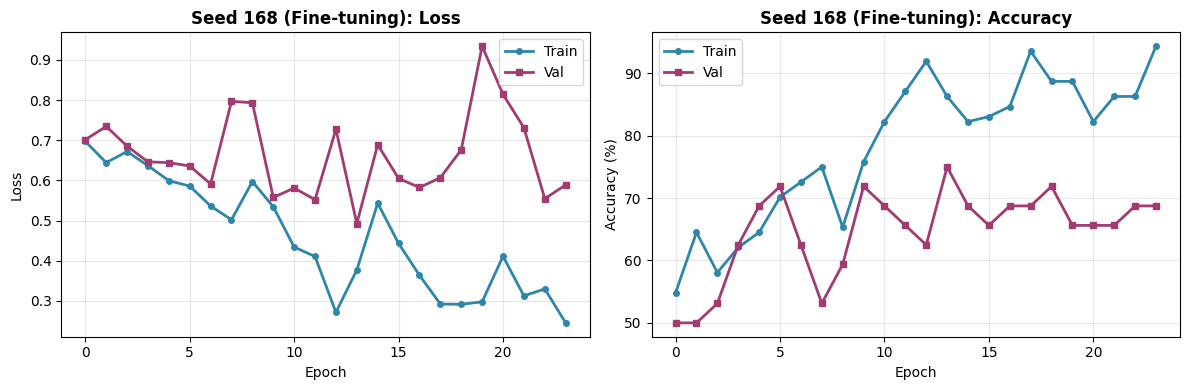

In [18]:
seed, metrics, history = train_finetune(
    seed=168,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device
)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed} (Fine-tuning)'
)


In [19]:
torch.cuda.empty_cache()

## 336

XLSR:Using original XLSR model
XLSR: Training layers 21 to 23

Training with seed 336
Class weights: Control=1.0, Dementia=1.2


Epoch 1 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 0.7242, Train Acc: 46.77% - Val Loss: 0.6956, Val Acc: 50.00% | Control: 0.00%, Dementia: 100.00%, F1: 0.6667
  *** New best model saved! (Acc: 50.00%, Loss: 0.6956) ***
      - Fine-tuned XLSR: best_xlsr.pth
      - Classifier: best_classifier.pth
      - Optimizer: optimizer.pth


Epoch 2 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 29/50 - Train Loss: 0.1454, Train Acc: 96.77% - Val Loss: 0.8053, Val Acc: 62.50% | Control: 43.75%, Dementia: 81.25%, F1: 0.6842


Epoch 30 - Training:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 30 - Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 30/50 - Train Loss: 0.1611, Train Acc: 94.35% - Val Loss: 0.8919, Val Acc: 53.12% | Control: 37.50%, Dementia: 68.75%, F1: 0.5946

Early stopping triggered after 10 epochs without improvement

Training completed for seed 336
Best Validation Accuracy: 71.88%
Best Validation Loss: 0.5797
F1 Score: 0.7097
Control Accuracy: 75.00%
Dementia Accuracy: 68.75%
Best epoch: 20
Stopped at epoch: 30



control_acc,▁▄▄▃▆▂▆▃▆▅▄▇▅▄▄▇▅▄▅▇▅▅▆█▃▄▆▆▅▄
dementia_acc,█▄▄▆▅▆▂▆▄▄▄▃▃▄▆▃▄▇▅▃▅▄▅▁▇▆▃▃▅▃
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
f1_score,▅▂▂▄█▃▃▄▇▄▂▆▂▃▇▇▄█▆▇▆▅█▄▇▆▄▅▆▁
train_acc,▁▃▂▃▄▃▄▅▅▆▅▆▆▇▆▇▇▇▇▇▇▇▇▆▇▇▇▇██
train_loss,█▇▇▇▇▇▆▆▅▅▅▄▅▃▄▃▃▃▂▂▃▃▃▃▂▃▃▃▁▁
val_acc,▁▂▂▂▇▁▅▂▇▄▂▇▃▃▅█▄▅▅█▅▅▇▇▄▄▅▆▅▂
val_loss,▃▄▄▃▃▄▂▆▄▃▆▃█▃▄▂▄▅▃▁▄▆▄▄▆▇▇▅▆▇
best_control_acc,0.75
best_dementia_acc,0.6875
best_epoch,20


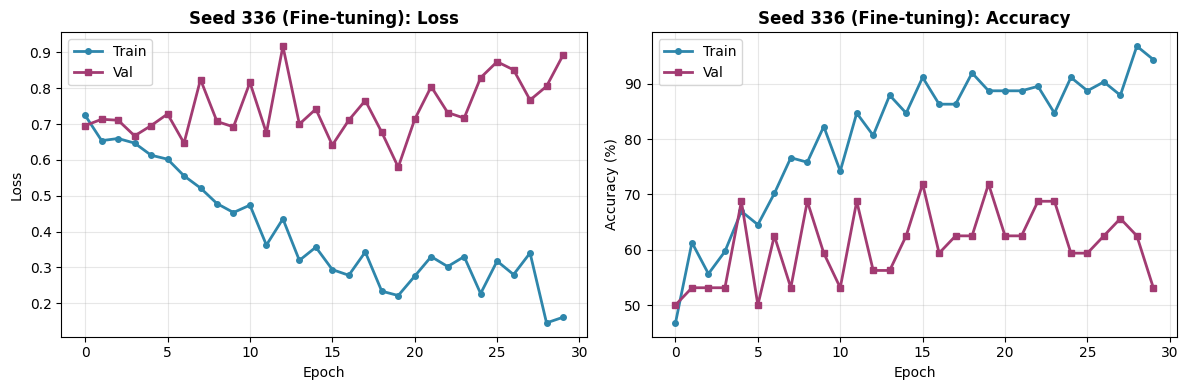

In [20]:
seed, metrics, history = train_finetune(
    seed=336,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device
)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed} (Fine-tuning)'
)


In [21]:
torch.cuda.empty_cache()

## Step 6: Summary of Results

In [22]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")


Mean Validation Accuracy: 78.75% ± 5.13%
Mean Validation Loss: 0.5090 ± 0.0860
Mean Control Accuracy: 78.75% ± 9.48%
Mean Dementia Accuracy: 78.75% ± 9.48%
Mean F1 Score: 0.7864 ± 0.0538

Detailed Results:
Seed 21: Acc=84.38%, Loss=0.3963, Control Acc=81.25%, Dementia Acc=87.50%, F1=0.8485
Seed 42: Acc=81.25%, Loss=0.4680, Control Acc=75.00%, Dementia Acc=87.50%, F1=0.8235
Seed 84: Acc=81.25%, Loss=0.6086, Control Acc=93.75%, Dementia Acc=68.75%, F1=0.7857
Seed 168: Acc=75.00%, Loss=0.4925, Control Acc=68.75%, Dementia Acc=81.25%, F1=0.7647
Seed 336: Acc=71.88%, Loss=0.5797, Control Acc=75.00%, Dementia Acc=68.75%, F1=0.7097


## Step 7: Test Best Model on Lu Dataset


In [23]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
# Find all indices with max accuracy
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
else:
    best_idx = max_acc_indices[0]

BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]
BEST_CONTROL_ACC = all_results['control_accs'][best_idx] * 100
BEST_DEMENTIA_ACC = all_results['dementia_accs'][best_idx] * 100

print(f"\nBest Model: Seed {BEST_SEED}")
print(f"Validation Accuracy: {BEST_VAL_ACC:.2f}%")
print(f"Validation Loss: {BEST_VAL_LOSS:.4f}")
print(f"F1 Score: {BEST_F1:.4f}")
print(f"Control Accuracy: {BEST_CONTROL_ACC:.2f}%")
print(f"Dementia Accuracy: {BEST_DEMENTIA_ACC:.2f}%")

BEST_MODEL_DIR = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}"
BEST_XLSR_PATH = BEST_MODEL_DIR / "best_xlsr.pth"
BEST_CLASSIFIER_PATH = BEST_MODEL_DIR / "best_classifier.pth"
print(f"\nModel Directory: {BEST_MODEL_DIR}")
print(f"XLSR Path: {BEST_XLSR_PATH}")
print(f"Classifier Path: {BEST_CLASSIFIER_PATH}")



Best Model: Seed 21
Validation Accuracy: 84.38%
Validation Loss: 0.3963
F1 Score: 0.8485
Control Accuracy: 81.25%
Dementia Accuracy: 87.50%

Model Directory: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed/seed_21
XLSR Path: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed/seed_21/best_xlsr.pth
Classifier Path: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed/seed_21/best_classifier.pth


In [ ]:
# Lu dataset configuration
TEST_DATASET = "Lu"
# Use raw audio directory for fine-tuning (loading original audio files)
LU_AUDIO_DIR = Path("/root/autodl-tmp/data/raw/Lu")
# CSV files are in processed directory
LU_CSV_PATH = Path("/root/autodl-tmp/data/processed") / f"{TEST_DATASET}-xlsr-test.csv"

# Collect audio files from Lu dataset and create CSV
test_samples = []

for label_dir in ["Control", "Dementia"]:
    label_audio_dir = LU_AUDIO_DIR / label_dir
    if not label_audio_dir.exists():
        print(f"Warning: Directory does not exist: {label_audio_dir}")
        continue
    
    label = 0 if label_dir == "Control" else 1
    
    # Find all audio files
    audio_files = list(label_audio_dir.glob("*.wav")) + list(label_audio_dir.glob("*.mp3")) + list(label_audio_dir.glob("*.flac"))
    print(f"Found {len(audio_files)} audio files in {label_dir}/")
    
    for audio_file in sorted(audio_files):
        session_id = audio_file.stem
        test_samples.append({
            "session_id": session_id,
            "ad": label
        })

# Create CSV for test dataset
test_df = pd.DataFrame(test_samples)
test_df.to_csv(LU_CSV_PATH, index=False)

print(f"\nLu Dataset Summary:")
print(f"Total samples: {len(test_samples)}")
print(f"Control: {sum(1 for s in test_samples if s['ad'] == 0)}")
print(f"Dementia: {sum(1 for s in test_samples if s['ad'] == 1)}")
print(f"CSV saved to: {LU_CSV_PATH}")

Found 36 audio files in Control/
Found 38 audio files in Dementia/

Lu Dataset Summary:
Total samples: 74
Control: 36
Dementia: 38
CSV saved to: /root/Lu-xlsr-test.csv


In [25]:
# Create test dataset and dataloader for Lu
lu_test_dataset = AudioDataset(
    csv_path=LU_CSV_PATH,
    audio_dir=LU_AUDIO_DIR,
    max_length_sec=AUDIO_LENGTH_SEC,
    sampling_rate=SAMPLING_RATE
)

lu_test_loader = DataLoader(
    lu_test_dataset,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_audio_batch,
    pin_memory=torch.cuda.is_available()
)

print(f"Lu test batches: {len(lu_test_loader)}")

Loaded 74 audio files
Control: 36, Dementia: 38

Lu test batches: 19


In [26]:
# Load the best fine-tuned model
print(f"Loading best model from seed {BEST_SEED}...")
print(f"  XLSR checkpoint: {BEST_XLSR_PATH}")
print(f"  Classifier checkpoint: {BEST_CLASSIFIER_PATH}")

# Create the fine-tuning model (same architecture as training)
test_model = XLSR_Finetune_Model(device=device, dropout=XLSR_DROPOUT)

# Load fine-tuned XLSR weights
xlsr_checkpoint = torch.load(BEST_XLSR_PATH, map_location=device, weights_only=False)
test_model.ssl_model.load_state_dict(xlsr_checkpoint['ssl_model_state_dict'])
print(f"  Loaded XLSR from epoch {xlsr_checkpoint['epoch']+1}, val_acc: {xlsr_checkpoint['best_val_acc']*100:.2f}%")

# Load classifier weights
classifier_checkpoint = torch.load(BEST_CLASSIFIER_PATH, map_location=device, weights_only=False)
test_model.classifier.load_state_dict(classifier_checkpoint['classifier_state_dict'])
print(f"  Loaded classifier from epoch {classifier_checkpoint['epoch']+1}")

test_model = test_model.to(device)
test_model.eval()

print(f"\nModel loaded successfully!")

Loading best model from seed 21...
  XLSR checkpoint: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed/seed_21/best_xlsr.pth
  Classifier checkpoint: /root/autodl-tmp/models/ADReSS_xlsr_finetune_multi_seed/seed_21/best_classifier.pth
XLSR:Using original XLSR model


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Training layers 21 to 23
  Loaded XLSR from epoch 30, val_acc: 84.38%
  Loaded classifier from epoch 30

Model loaded successfully!


In [27]:
# Test on Lu dataset
from sklearn.metrics import accuracy_score, f1_score as sklearn_f1_score

# Perform predictions
all_preds = []
all_labels = []
all_probs = []

test_model.eval()
with torch.no_grad():
    for waveforms, labels in tqdm(lu_test_loader, desc=f"Testing on {TEST_DATASET}"):
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        
        logits = test_model(waveforms)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate overall metrics
lu_accuracy = accuracy_score(all_labels, all_preds)
lu_f1 = sklearn_f1_score(all_labels, all_preds, pos_label=1)

# Calculate per-class accuracy
control_mask = all_labels == 0
dementia_mask = all_labels == 1

lu_control_acc = np.mean(all_preds[control_mask] == all_labels[control_mask]) if control_mask.sum() > 0 else 0
lu_dementia_acc = np.mean(all_preds[dementia_mask] == all_labels[dementia_mask]) if dementia_mask.sum() > 0 else 0

print(f"\n{'='*60}")
print(f"Test Results on {TEST_DATASET} Dataset")
print(f"{'='*60}")
print(f"Overall Accuracy: {lu_accuracy*100:.2f}%")
print(f"F1 Score: {lu_f1:.4f}")
print(f"Control Accuracy: {lu_control_acc*100:.2f}%")
print(f"Dementia Accuracy: {lu_dementia_acc*100:.2f}%")
print(f"{'='*60}")

Testing on Lu:   0%|          | 0/19 [00:00<?, ?it/s]

/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3


Test Results on Lu Dataset
Overall Accuracy: 50.00%
F1 Score: 0.4789
Control Accuracy: 55.56%
Dementia Accuracy: 44.74%


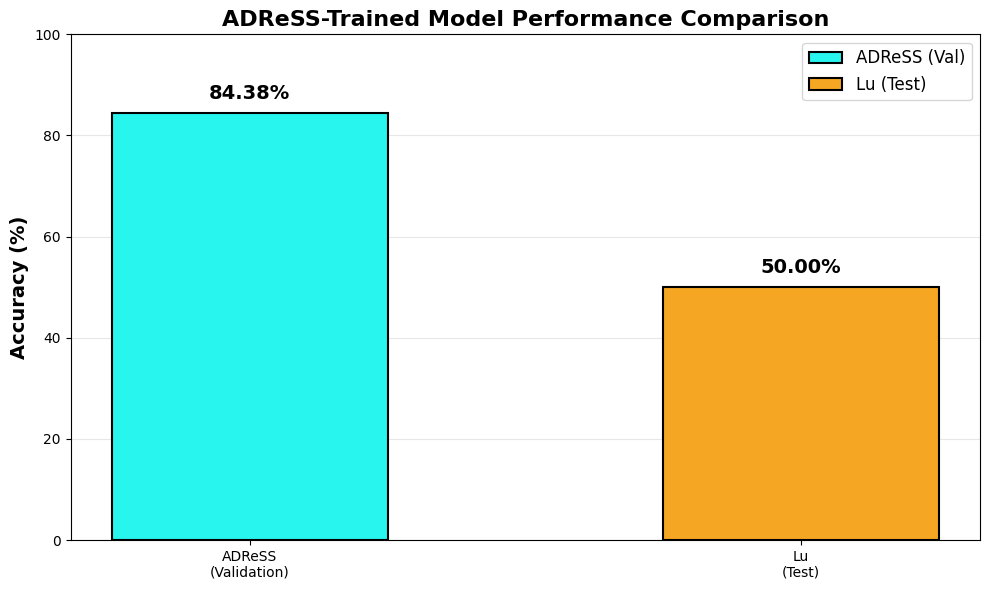


FINAL COMPARISON: ADReSS vs Lu

ADReSS Dataset (Validation - Best Seed 21):
  Overall Accuracy: 84.38%
  F1 Score: 0.8485
  Control Accuracy: 81.25%
  Dementia Accuracy: 87.50%

Lu Dataset (Test):
  Overall Accuracy: 50.00%
  F1 Score: 0.4789
  Control Accuracy: 55.56%
  Dementia Accuracy: 44.74%

Performance Difference: -34.38%


In [28]:
# Performance Comparison Visualization
import matplotlib.pyplot as plt

# Set font properties
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Prepare data for visualization
dataset_names = [f"{DATASET_NAME}\n(Validation)", f"{TEST_DATASET}\n(Test)"]
accuracies = [BEST_VAL_ACC, lu_accuracy * 100]

# Set distinct colors for each dataset
PITT_COLOR = '#27F5EE'   # Blue for Pitt
LU_COLOR = '#F5A623'     # Red for Lu
colors = [PITT_COLOR, LU_COLOR]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(dataset_names, accuracies, color=colors, edgecolor='black', linewidth=1.5, width=0.5)

# Set labels and title
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title(f'{DATASET_NAME}-Trained Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{acc:.2f}%',
            ha='center', va='bottom',
            fontweight='bold', fontsize=14, color='black')

# Add legend
ax.legend(bars, [f'{DATASET_NAME} (Val)', f'{TEST_DATASET} (Test)'], 
          loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

# Print comprehensive summary
print(f"\n{'='*70}")
print(f"FINAL COMPARISON: {DATASET_NAME} vs {TEST_DATASET}")
print(f"{'='*70}")

print(f"\n{DATASET_NAME} Dataset (Validation - Best Seed {BEST_SEED}):")
print(f"  Overall Accuracy: {BEST_VAL_ACC:.2f}%")
print(f"  F1 Score: {BEST_F1:.4f}")
print(f"  Control Accuracy: {BEST_CONTROL_ACC:.2f}%")
print(f"  Dementia Accuracy: {BEST_DEMENTIA_ACC:.2f}%")

print(f"\n{TEST_DATASET} Dataset (Test):")
print(f"  Overall Accuracy: {lu_accuracy*100:.2f}%")
print(f"  F1 Score: {lu_f1:.4f}")
print(f"  Control Accuracy: {lu_control_acc*100:.2f}%")
print(f"  Dementia Accuracy: {lu_dementia_acc*100:.2f}%")

perf_diff = lu_accuracy*100 - BEST_VAL_ACC
print(f"\nPerformance Difference: {perf_diff:+.2f}%")
print(f"{'='*70}")
